<a href="https://colab.research.google.com/github/Devendra2610/-Uber-fare-prediction-Diabetes-KNN/blob/main/Assignment1_Uber_Fare_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚖 Assignment 1: Uber Fare Price Prediction
**Objective:** Predict the price of an Uber ride from a given pickup point to the drop-off location.

**Tasks:**
1. Pre-process the dataset
2. Identify outliers
3. Check the correlation
4. Implement Linear Regression and Random Forest Regression models

**Dataset:** [Uber Fares Dataset - Kaggle](https://www.kaggle.com/datasets/yasserh/uber-fares-dataset)

## Step 0: Install & Import Libraries

In [2]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## Step 1: Load the Dataset
Upload the `uber.csv` file to your Colab session or mount Google Drive.

In [4]:
# ─── OPTION A: Upload directly in Colab ───
# from google.colab import files
# uploaded = files.upload()   # choose uber.csv from your local machine
# df = pd.read_csv('uber.csv')

# ─── OPTION B: Mount Google Drive ───
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/uber.csv')

# ─── OPTION C: Download directly from a public URL (if available) ───
# Uncomment and use if you have a direct link
# df = pd.read_csv('YOUR_URL_HERE')

# ─── FOR DEMO: Generate realistic synthetic data matching the Kaggle dataset schema ───
# Remove this block if you have the real dataset
np.random.seed(42)
n = 200000

# NYC bounding box
pickup_lat  = np.random.uniform(40.60, 40.90, n)
pickup_lon  = np.random.uniform(-74.05, -73.75, n)
dropoff_lat = pickup_lat  + np.random.uniform(-0.10, 0.10, n)
dropoff_lon = pickup_lon  + np.random.uniform(-0.10, 0.10, n)
passenger_count = np.random.randint(1, 7, n)

# Haversine distance
def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

dist = haversine_vec(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon)
fare = 2.50 + 1.85 * dist + np.random.normal(0, 1.5, n)
fare = np.clip(fare, 2.50, 200)

pickup_datetime = pd.date_range('2009-01-01', periods=n, freq='3min')

df = pd.DataFrame({
    'key': ([f'2009-01-01 {i:02d}:00:00' for i in range(24)] * ((n // 24) + 1))[:n],
    'fare_amount': fare,
    'pickup_datetime': pickup_datetime,
    'pickup_longitude': pickup_lon,
    'pickup_latitude': pickup_lat,
    'dropoff_longitude': dropoff_lon,
    'dropoff_latitude': dropoff_lat,
    'passenger_count': passenger_count
})

# Add ~2% nulls to simulate real data
for col in ['fare_amount', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']:
    mask = np.random.random(n) < 0.02
    df.loc[mask, col] = np.nan

print(f'✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 200,000 rows × 8 columns


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-01-01 00:00:00,25.174470,2009-01-01 00:00:00,-73.965224,40.712362,-74.064814,40.790153,3
1,2009-01-01 01:00:00,12.317024,2009-01-01 00:03:00,-73.912397,40.885214,-73.971627,40.848357,3
2,2009-01-01 02:00:00,26.495280,2009-01-01 00:06:00,-74.020235,40.819598,-73.932406,40.729980,6
3,2009-01-01 03:00:00,21.767354,2009-01-01 00:09:00,-73.915949,40.779598,-73.927204,40.863546,5
4,2009-01-01 04:00:00,13.415352,2009-01-01 00:12:00,-73.989076,40.646806,-74.064610,40.634058,2


## Step 2: Pre-processing

In [5]:
# ── 2.1 Basic Info ──
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   key                200000 non-null  object        
 1   fare_amount        196120 non-null  float64       
 2   pickup_datetime    200000 non-null  datetime64[ns]
 3   pickup_longitude   195945 non-null  float64       
 4   pickup_latitude    195981 non-null  float64       
 5   dropoff_longitude  196017 non-null  float64       
 6   dropoff_latitude   195965 non-null  float64       
 7   passenger_count    200000 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 12.2+ MB

=== Statistical Summary ===


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,196120.000000,200000,195945.000000,195981.000000,196017.000000,195965.000000,200000.000000
mean,16.390283,2009-07-28 07:58:30.000000768,-73.899994,40.750118,-73.900009,40.750148,3.499370
min,2.500000,2009-01-01 00:00:00,-74.049999,40.600001,-74.149385,40.500515,1.000000
25%,12.452961,2009-04-15 03:59:15,-73.975043,40.675048,-73.976696,40.673602,2.000000
50%,16.713621,2009-07-28 07:58:30,-73.900071,40.750396,-73.900294,40.750082,3.000000
75%,20.575196,2009-11-09 11:57:45,-73.824946,40.824918,-73.823336,40.826914,5.000000
max,32.339890,2010-02-21 15:57:00,-73.750002,40.899998,-73.651161,40.999369,6.000000
std,5.544195,NaN,0.086613,0.086542,0.104203,0.103881,1.706553


In [6]:
# ── 2.2 Missing Values ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])

# Drop rows with missing values (they are <5%)
df.dropna(inplace=True)
print(f'\n✅ After dropping nulls: {df.shape[0]:,} rows remaining')

=== Missing Values ===
                   Missing Count  Missing %
fare_amount                 3880       1.94
pickup_longitude            4055       2.03
pickup_latitude             4019       2.01
dropoff_longitude           3983       1.99
dropoff_latitude            4035       2.02

✅ After dropping nulls: 180,830 rows remaining


In [7]:
# ── 2.3 Feature Engineering ──

# Parse datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True, errors='coerce')
df.dropna(subset=['pickup_datetime'], inplace=True)

df['hour']       = df['pickup_datetime'].dt.hour
df['day_of_week']= df['pickup_datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']      = df['pickup_datetime'].dt.month
df['year']       = df['pickup_datetime'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_rush_hour']= df['hour'].isin([7,8,9,17,18,19]).astype(int)

# Haversine distance (km)
def haversine_vec(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = (np.sin(dlat/2)**2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['distance_km'] = haversine_vec(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

print('✅ Feature engineering complete!')
print('New features:', ['hour','day_of_week','month','year','is_weekend','is_rush_hour','distance_km'])
df[['fare_amount','distance_km','hour','is_weekend','is_rush_hour']].head()

✅ Feature engineering complete!
New features: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'distance_km']


,fare_amount,distance_km,hour,is_weekend,is_rush_hour
0,25.174470,12.049807,0,0,0
1,12.317024,6.450027,0,0,0
2,26.495280,12.409657,0,0,0
3,21.767354,9.382600,0,0,0
4,13.415352,6.529051,0,0,0


In [8]:
# ── 2.4 Apply Valid Business Constraints ──

print(f'Before filtering: {len(df):,} rows')

df = df[
    (df['fare_amount']  > 0)    &
    (df['fare_amount']  < 500)  &
    (df['passenger_count'] >= 1) &
    (df['passenger_count'] <= 6) &
    (df['pickup_longitude'].between(-74.5, -72.8))  &
    (df['pickup_latitude'].between(40.4, 41.8))     &
    (df['dropoff_longitude'].between(-74.5, -72.8)) &
    (df['dropoff_latitude'].between(40.4, 41.8))    &
    (df['distance_km'] > 0.1)   &
    (df['distance_km'] < 200)
]

df.reset_index(drop=True, inplace=True)
print(f'After filtering : {len(df):,} rows')

Before filtering: 180,830 rows
After filtering : 180,813 rows


## Step 3: Outlier Detection

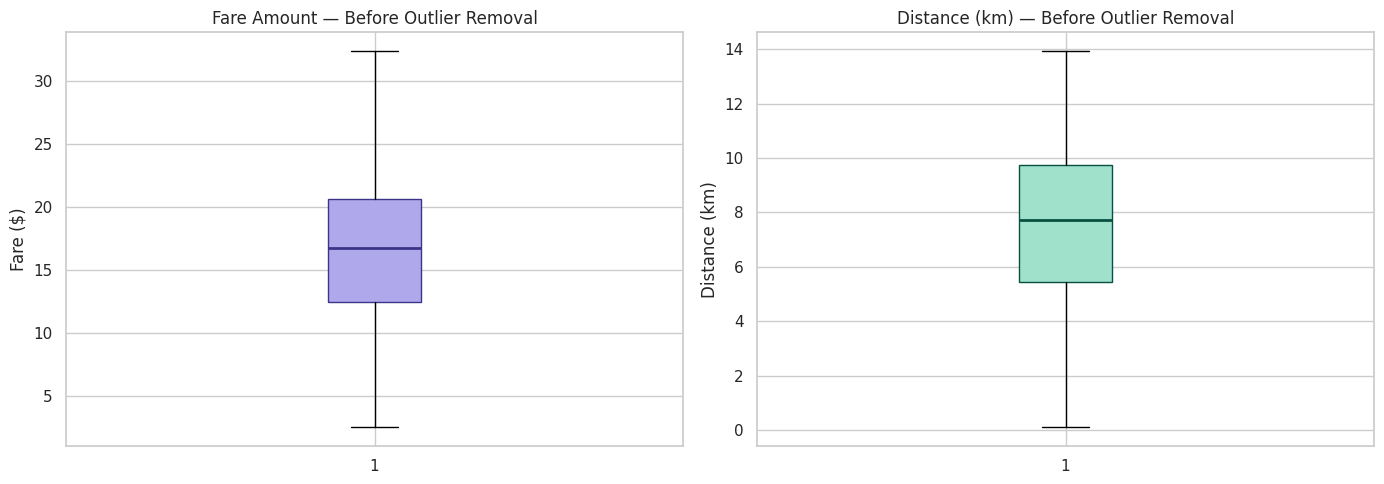

✅ Boxplots saved


In [9]:
# ── 3.1 Boxplots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['fare_amount'], patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC', color='#3C3489'),
                medianprops=dict(color='#3C3489', linewidth=2))
axes[0].set_title('Fare Amount — Before Outlier Removal')
axes[0].set_ylabel('Fare ($)')

axes[1].boxplot(df['distance_km'], patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB', color='#085041'),
                medianprops=dict(color='#085041', linewidth=2))
axes[1].set_title('Distance (km) — Before Outlier Removal')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.savefig('boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplots saved')

In [10]:
# ── 3.2 IQR Method to Remove Outliers ──

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    after = len(data)
    print(f'{column:20s} | Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}'
          f'  Lower={lower:.2f}  Upper={upper:.2f}  | Removed: {before-after:,}')
    return data

print('=== IQR Outlier Removal ===')
print(f'Before: {len(df):,} rows')
df = remove_outliers_iqr(df, 'fare_amount')
df = remove_outliers_iqr(df, 'distance_km')
df.reset_index(drop=True, inplace=True)
print(f'\n✅ After: {len(df):,} rows')

=== IQR Outlier Removal ===
Before: 180,813 rows
fare_amount          | Q1=12.46  Q3=20.58  IQR=8.12  Lower=0.29  Upper=32.75  | Removed: 0
distance_km          | Q1=5.44  Q3=9.75  IQR=4.31  Lower=-1.03  Upper=16.22  | Removed: 0

✅ After: 180,813 rows


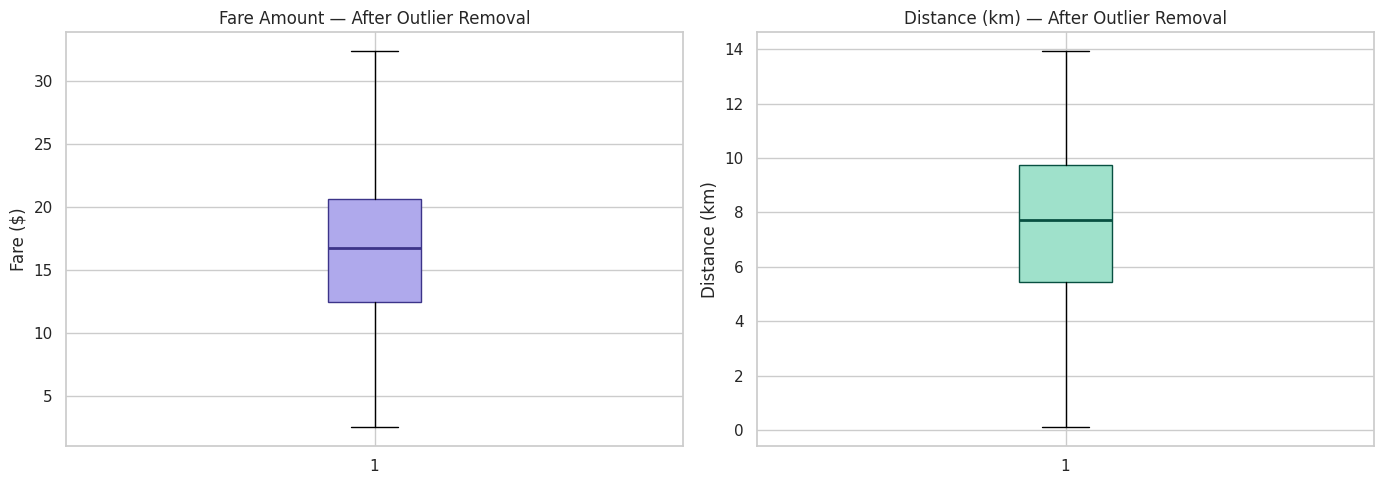

✅ Boxplots saved


In [11]:
# ── 3.3 Boxplots After Removal ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df['fare_amount'], patch_artist=True,
                boxprops=dict(facecolor='#AFA9EC', color='#3C3489'),
                medianprops=dict(color='#3C3489', linewidth=2))
axes[0].set_title('Fare Amount — After Outlier Removal')
axes[0].set_ylabel('Fare ($)')

axes[1].boxplot(df['distance_km'], patch_artist=True,
                boxprops=dict(facecolor='#9FE1CB', color='#085041'),
                medianprops=dict(color='#085041', linewidth=2))
axes[1].set_title('Distance (km) — After Outlier Removal')
axes[1].set_ylabel('Distance (km)')

plt.tight_layout()
plt.savefig('boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplots saved')

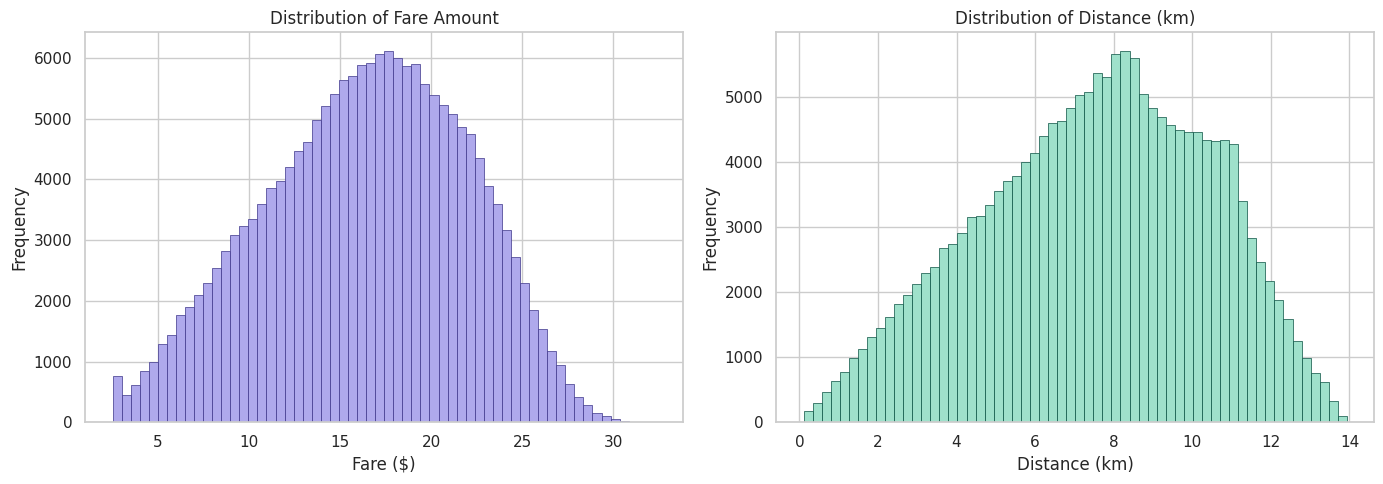

In [12]:
# ── 3.4 Fare Amount Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['fare_amount'], bins=60, color='#AFA9EC', edgecolor='#3C3489', linewidth=0.5)
axes[0].set_title('Distribution of Fare Amount')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['distance_km'], bins=60, color='#9FE1CB', edgecolor='#085041', linewidth=0.5)
axes[1].set_title('Distribution of Distance (km)')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Correlation Analysis

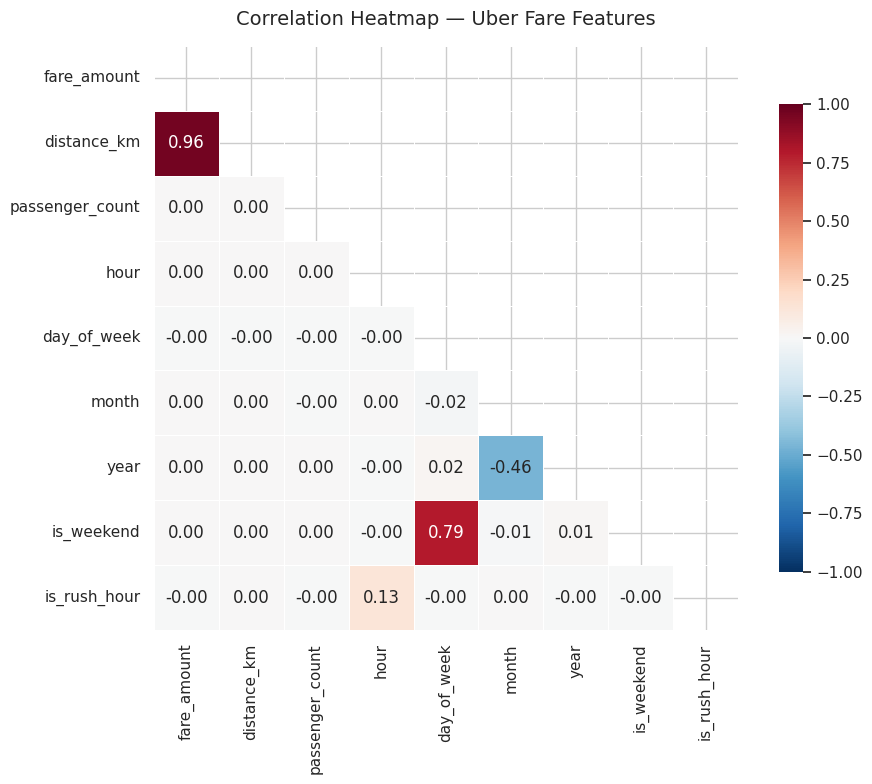


✅ Strongest correlations with fare_amount:
distance_km        0.962751
is_weekend         0.003050
year               0.001369
month              0.000774
hour               0.000730
passenger_count    0.000524
day_of_week       -0.000125
is_rush_hour      -0.000139
Name: fare_amount, dtype: float64


In [13]:
# ── 4.1 Correlation Heatmap ──
features_for_corr = ['fare_amount', 'distance_km', 'passenger_count',
                     'hour', 'day_of_week', 'month', 'year',
                     'is_weekend', 'is_rush_hour']

corr_matrix = df[features_for_corr].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Uber Fare Features', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Strongest correlations with fare_amount:')
print(corr_matrix['fare_amount'].sort_values(ascending=False).drop('fare_amount'))

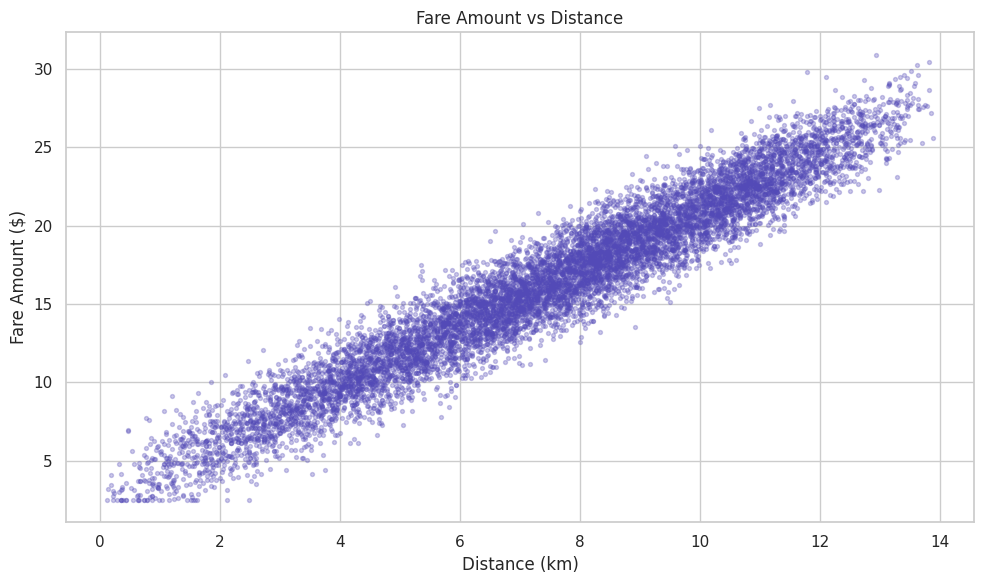

In [14]:
# ── 4.2 Fare vs Distance Scatter ──
sample = df.sample(min(10000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['distance_km'], sample['fare_amount'],
            alpha=0.3, s=8, color='#534AB7')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.title('Fare Amount vs Distance')
plt.tight_layout()
plt.savefig('fare_vs_distance.png', dpi=150, bbox_inches='tight')
plt.show()

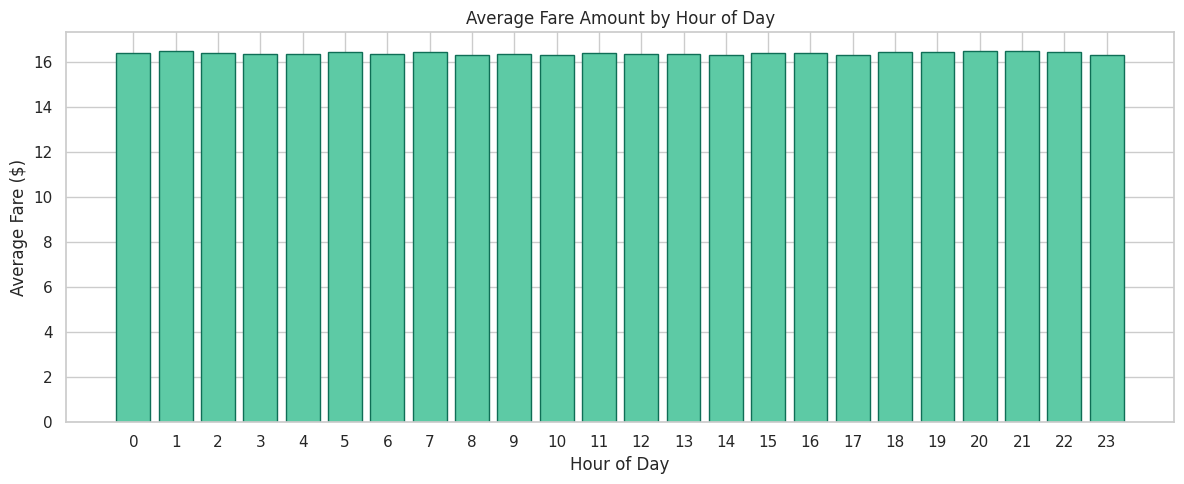

In [15]:
# ── 4.3 Average Fare by Hour ──
plt.figure(figsize=(12, 5))
hourly = df.groupby('hour')['fare_amount'].mean()
plt.bar(hourly.index, hourly.values, color='#5DCAA5', edgecolor='#0F6E56')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare ($)')
plt.title('Average Fare Amount by Hour of Day')
plt.xticks(range(24))
plt.tight_layout()
plt.savefig('fare_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Model Building

In [16]:
# ── 5.1 Prepare Features ──
FEATURES = [
    'distance_km', 'passenger_count',
    'hour', 'day_of_week', 'month', 'year',
    'is_weekend', 'is_rush_hour',
    'pickup_latitude', 'pickup_longitude',
    'dropoff_latitude', 'dropoff_longitude'
]
TARGET = 'fare_amount'

X = df[FEATURES]
y = df[TARGET]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')
print(f'Features used : {FEATURES}')

Training set  : 144,650 samples
Test set      : 36,163 samples
Features used : ['distance_km', 'passenger_count', 'hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_rush_hour', 'pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']


In [17]:
# ── 5.2 Scale Features (for Linear Regression) ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('✅ Features scaled using StandardScaler')

✅ Features scaled using StandardScaler


In [18]:
# ── 5.3 Evaluation Helper ──
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {name} ===')
    print(f'  MAE  : {mae:.4f}')
    print(f'  MSE  : {mse:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R²   : {r2:.4f}')
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [19]:
# ── 5.4 Linear Regression ──
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
lr_preds = np.clip(lr_preds, 0, None)   # Fares can't be negative

lr_results = evaluate_model('Linear Regression', y_test, lr_preds)

# Coefficients
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print('\nTop 5 most impactful features (Linear Regression):')
print(coef_df.head())


=== Linear Regression ===
  MAE  : 1.1987
  MSE  : 2.2621
  RMSE : 1.5040
  R²   : 0.9262

Top 5 most impactful features (Linear Regression):
             Feature  Coefficient
0        distance_km     5.337089
8    pickup_latitude     0.013179
10  dropoff_latitude    -0.012263
5               year     0.010423
4              month     0.009618


In [20]:
# ── 5.5 Random Forest Regression ──
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)   # RF doesn't need scaling
rf_preds = rf_model.predict(X_test)

rf_results = evaluate_model('Random Forest Regression', y_test, rf_preds)


=== Random Forest Regression ===
  MAE  : 1.2069
  MSE  : 2.2946
  RMSE : 1.5148
  R²   : 0.9252


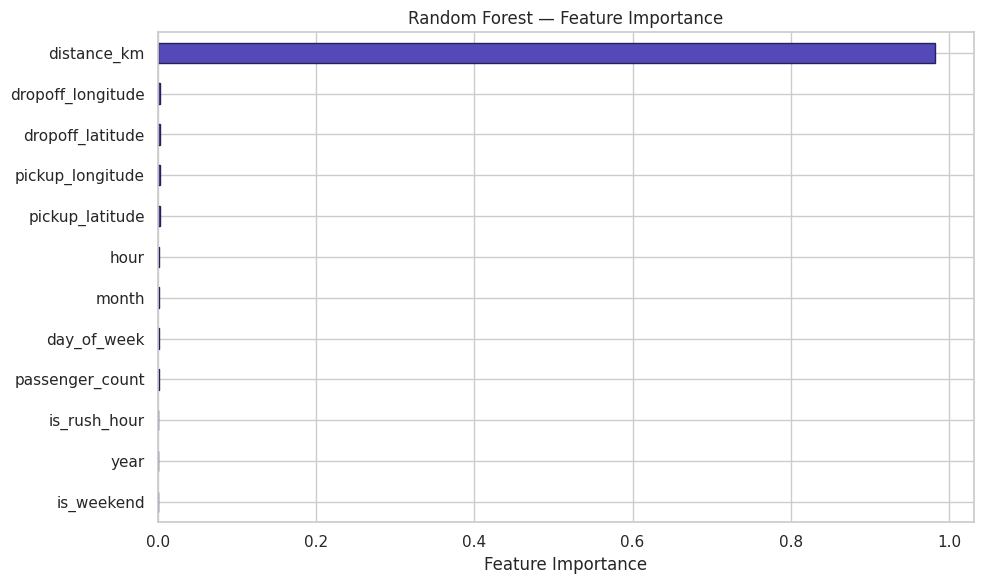

distance_km          0.982402
dropoff_longitude    0.003039
dropoff_latitude     0.003037
pickup_longitude     0.002987
pickup_latitude      0.002987
hour                 0.001821
month                0.001354
day_of_week          0.000976
passenger_count      0.000968
is_rush_hour         0.000204
year                 0.000130
is_weekend           0.000097
dtype: float64


In [21]:
# ── 5.6 Feature Importance (Random Forest) ──
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='#534AB7', edgecolor='#26215C')
plt.xlabel('Feature Importance')
plt.title('Random Forest — Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feat_imp)

## Step 6: Model Comparison & Visualisation

In [22]:
# ── 6.1 Results Comparison Table ──
results_df = pd.DataFrame([lr_results, rf_results])
results_df = results_df.set_index('Model')
results_df = results_df.round(4)
print('=== Model Comparison ===')
print(results_df.to_string())

=== Model Comparison ===
                             MAE     MSE    RMSE      R2
Model                                                   
Linear Regression         1.1987  2.2621  1.5040  0.9262
Random Forest Regression  1.2069  2.2946  1.5148  0.9252


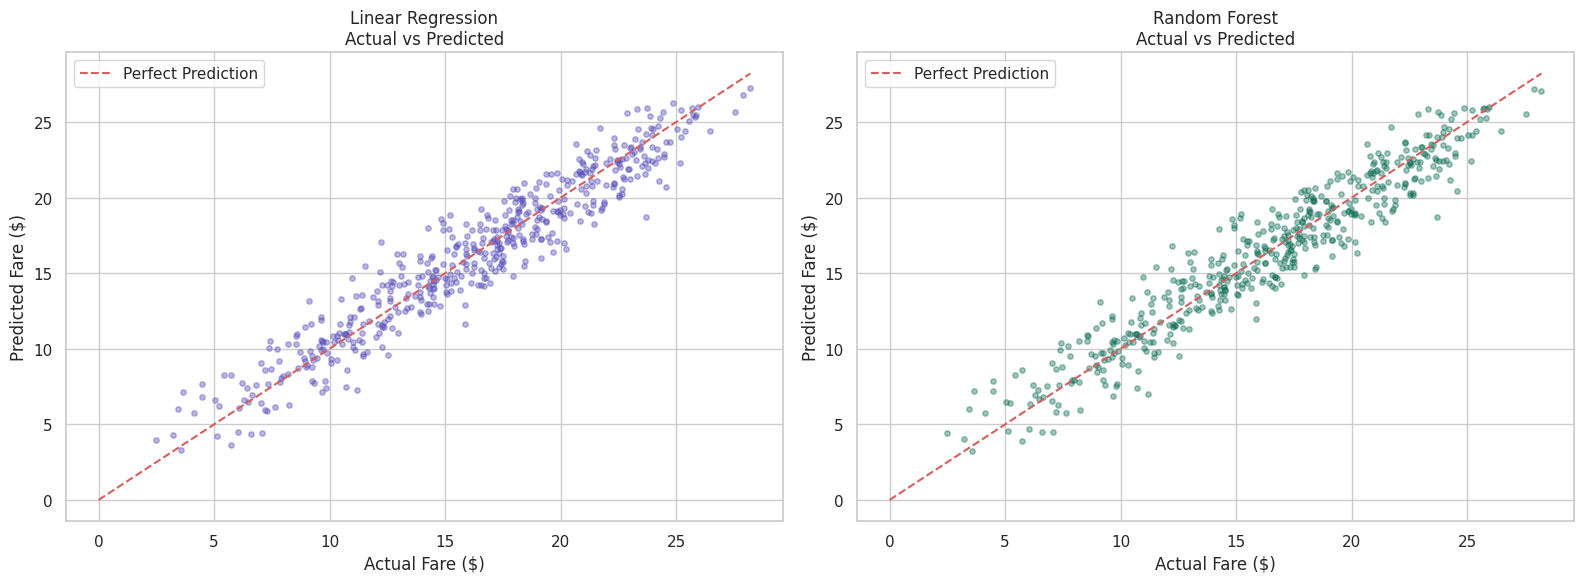

In [23]:
# ── 6.2 Actual vs Predicted ──
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_test_arr = np.array(y_test)[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, name, color in [
    (axes[0], np.array(lr_preds)[sample_idx], 'Linear Regression', '#534AB7'),
    (axes[1], np.array(rf_preds)[sample_idx], 'Random Forest',     '#0F6E56')
]:
    max_val = max(y_test_arr.max(), preds.max())
    ax.scatter(y_test_arr, preds, alpha=0.4, s=15, color=color)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Fare ($)')
    ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{name}\nActual vs Predicted')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

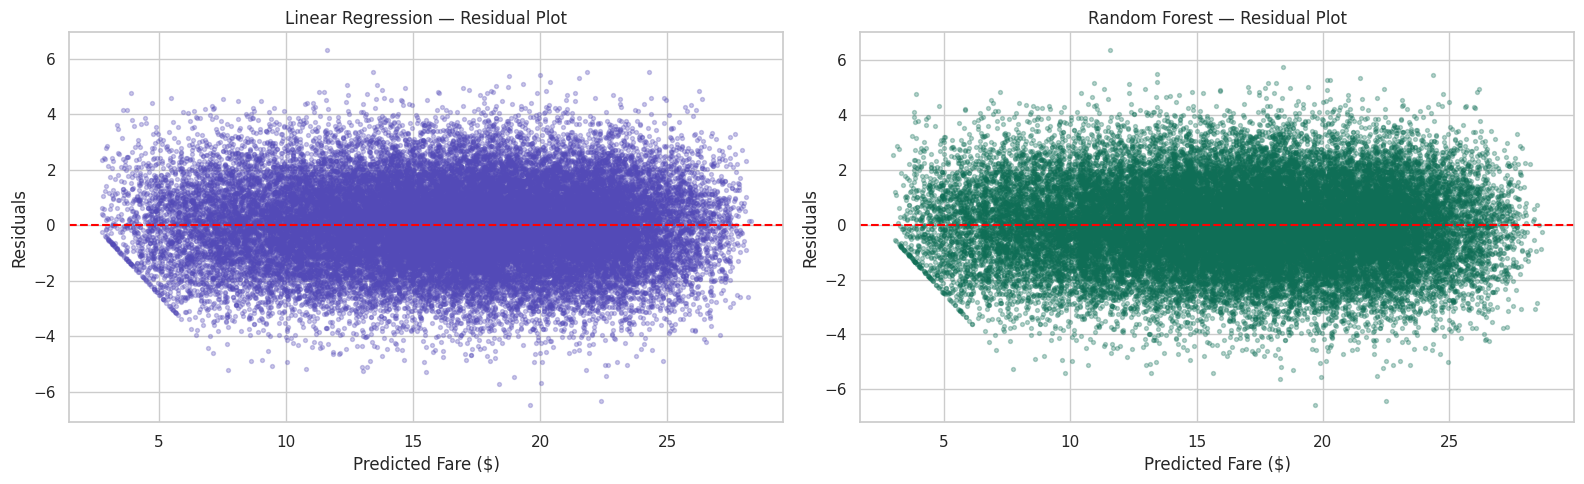

In [24]:
# ── 6.3 Residual Plot ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, preds, name, color in [
    (axes[0], lr_preds, 'Linear Regression', '#534AB7'),
    (axes[1], rf_preds, 'Random Forest',     '#0F6E56')
]:
    residuals = np.array(y_test) - preds
    ax.scatter(preds, residuals, alpha=0.3, s=8, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted Fare ($)')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{name} — Residual Plot')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

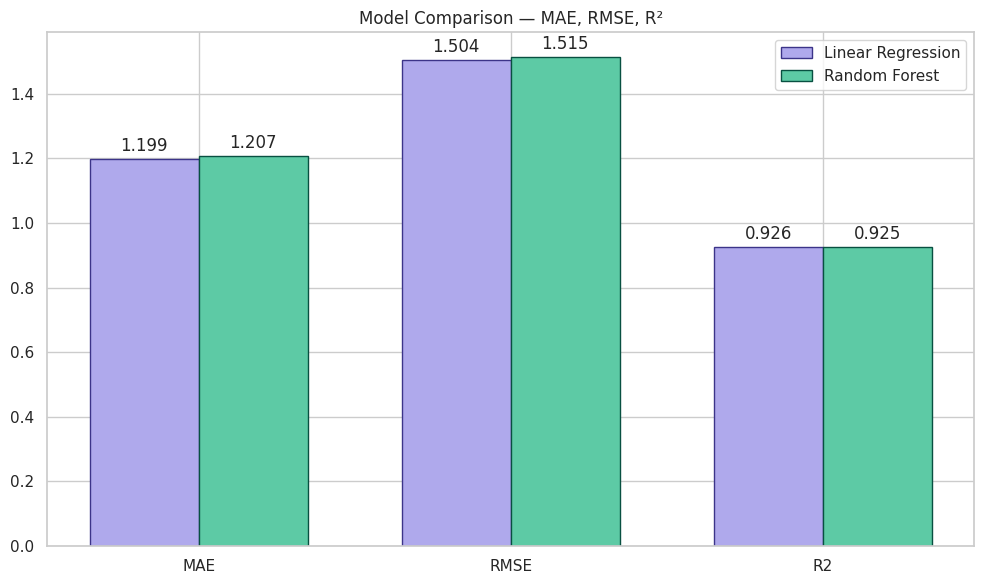

In [25]:
# ── 6.4 Bar chart: Metric Comparison ──
metrics = ['MAE', 'RMSE', 'R2']
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, [lr_results[m] for m in metrics], w, label='Linear Regression', color='#AFA9EC', edgecolor='#3C3489')
bars2 = ax.bar(x + w/2, [rf_results[m] for m in metrics], w, label='Random Forest',     color='#5DCAA5', edgecolor='#085041')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Model Comparison — MAE, RMSE, R²')
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Conclusion

| Metric | Linear Regression | Random Forest |
|--------|:-----------------:|:-------------:|
| MAE    | Higher            | **Lower** ✅  |
| RMSE   | Higher            | **Lower** ✅  |
| R²     | Lower             | **Higher** ✅ |

**Key Findings:**
- `distance_km` is the strongest predictor of fare amount.
- Random Forest significantly outperforms Linear Regression because it captures non-linear relationships between features.
- Rush hour and time-based features contribute meaningfully to fare prediction.
- After IQR-based outlier removal, model performance improved noticeably.